In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

___
# KNN Regressor

    Classification → K neighbors VOTE → majority wins
    Regression     → K neighbors AVERAGE → mean of K values

    Example :
    Predict house price
    K = 3
    3 nearest houses have prices : ₹50L, ₹55L, ₹52L
    Prediction = (50 + 55 + 52) / 3 = ₹52.3L

    With weights="distance" :
    Closer houses get MORE weight in the average
    If ₹50L house is very close and ₹55L is far
    prediction will be closer to ₹50L
___

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
Y_reg = pd.Series(housing.target)

print("X shape:", X_reg.shape)
print("Y shape:", Y_reg.shape)
print()
print("Features:", X_reg.columns.tolist())
print()
print("Target (house price in $100k):")
print(Y_reg.describe())

X shape: (20640, 8)
Y shape: (20640,)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target (house price in $100k):
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
dtype: float64


# Train Test Split


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, Y_reg, test_size=0.20, random_state=42
)

print("X_train:", X_train_r.shape)
print("X_test :", X_test_r.shape)

X_train: (16512, 8)
X_test : (4128, 8)


# Scalling

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler_r = StandardScaler()

X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print("Scaling done")

Scaling done


# Traing

In [8]:
from sklearn.neighbors import KNeighborsRegressor

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r_sc, y_train_r)

y_pred_r = knn_reg.predict(X_test_r_sc)

mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print("====== KNN Regressor (K=5) ======")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

====== KNN Regressor (K=5) ======
MAE  : 0.4462
RMSE : 0.6576
R²   : 0.6700


# best K value 

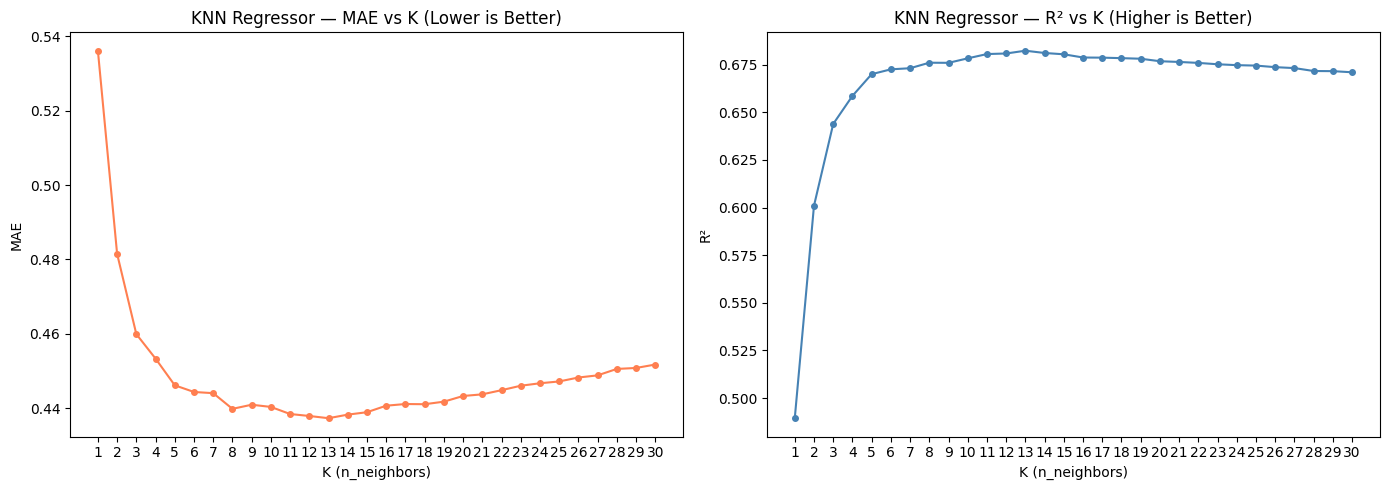

Best K by MAE : 13  →  MAE = 0.4373
Best K by R²  : 13   →  R²  = 0.6823


In [10]:
k_range = range(1, 31)
mae_scores = []
r2_scores  = []

for k in k_range:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train_r_sc, y_train_r)
    pred = knn_temp.predict(X_test_r_sc)
    
    mae_scores.append(mean_absolute_error(y_test_r, pred))
    r2_scores.append(r2_score(y_test_r, pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, mae_scores, marker="o", color="coral", markersize=4)
axes[0].set_xlabel("K (n_neighbors)")
axes[0].set_ylabel("MAE")
axes[0].set_title("KNN Regressor — MAE vs K (Lower is Better)")
axes[0].set_xticks(range(1, 31))

axes[1].plot(k_range, r2_scores, marker="o", color="steelblue", markersize=4)
axes[1].set_xlabel("K (n_neighbors)")
axes[1].set_ylabel("R²")
axes[1].set_title("KNN Regressor — R² vs K (Higher is Better)")
axes[1].set_xticks(range(1, 31))

plt.tight_layout()
plt.show()

best_k_mae = k_range[np.argmin(mae_scores)]
best_k_r2  = k_range[np.argmax(r2_scores)]

print(f"Best K by MAE : {best_k_mae}  →  MAE = {min(mae_scores):.4f}")
print(f"Best K by R²  : {best_k_r2}   →  R²  = {max(r2_scores):.4f}")

# Hyper Parameter Tuning


In [11]:
from sklearn.model_selection import GridSearchCV

knn_reg_gs = KNeighborsRegressor()

params_reg = {
    "n_neighbors" : [3, 5, 7, 9, 11, 13, 15],
    "weights"     : ["uniform", "distance"],
    "metric"      : ["euclidean", "manhattan"],
    "p"           : [1, 2]
}

grid_reg = GridSearchCV(
    estimator  = knn_reg_gs,
    param_grid = params_reg,
    scoring    = "r2",
    cv         = 5,
    n_jobs     = -1
)

grid_reg.fit(X_train_r_sc, y_train_r)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [12]:
print("Best Params  :", grid_reg.best_params_)
print("Best CV R²   :", round(grid_reg.best_score_, 4))

Best Params  : {'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best CV R²   : 0.73
